# 实验13: 改进 LeNet-5 实现手写数字+字母混合识别 (EMNIST)

**实验性质**: 设计性实验 (Design Experiment)  
**数据集**: EMNIST (Extended MNIST) - Balanced Split (47类)  
**核心模型**: Improved LeNet-5 (ReLU + MaxPool + Dropout)

## 1. 实验背景与意义

###  知识点：从 MNIST 到 EMNIST
我们在入门时都跑过 MNIST（0-9 数字识别）。但在现实 OCR（光学字符识别）场景中，数字往往和字母混合出现（如车牌号、验证码、手写表单）。
**EMNIST (Extended MNIST)** 是 NIST 提供的一个更具挑战性的数据集，它包含 0-9, A-Z, a-z。

###  设计目标
1.  **模型改进**: 原始 LeNet-5 是 1998 年提出的，使用 Sigmoid 和 AveragePooling。本实验要求你将其改进为现代 CNN 结构（**ReLU, MaxPooling, Dropout**）以适应更复杂的 47 分类任务。
2.  **混淆分析**: 数字 `0` 和字母 `O`，数字 `1` 和字母 `l` 长得非常像。我们将分析模型是否会“脸盲”。
3.  **数据坑点处理**: EMNIST 数据集在 PyTorch 中默认是**旋转 90 度并翻转**的，我们需要在预处理阶段修正它。

In [ ]:
# 1. 环境准备
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" 运行设备: {device}")

🔥 运行设备: cuda


## 2. 数据集加载与预处理 (ETL)

EMNIST 有多种切分方式（ByClass, ByMerge, Balanced 等）。
为了平衡训练速度和难度，我们选择 **'split="balanced"'**：
* **类别数**: 47 类 (0-9, A-Z, a-z 的部分合并)
* **特点**: 每一类的样本数相同，避免模型偏向某一类。

** 关键代码**: EMNIST 原始数据是横着的，我们需要编写一个 `transpose` 变换来把它扶正。

In [2]:
# 定义 EMNIST 映射表 (Index -> Character)
# EMNIST Balanced 映射: 0-9 是数字, 10-35 是大写, 36-46 是小写(部分)
EMNIST_MAPPING = {i: str(i) for i in range(10)}
EMNIST_MAPPING.update({i+10: chr(65+i) for i in range(26)}) # A-Z
EMNIST_MAPPING.update({i+36: 'abdefghnqrt'[i] for i in range(11)}) # a-z (部分与大写合并)

def custom_transforms():
    return transforms.Compose([
        transforms.ToTensor(),
        # EMNIST 默认是旋转90度且翻转的，必须旋转回来才能正常看
        lambda x: x.transpose(2, 1) 
    ])

print(" 正在下载/加载 EMNIST 数据集 (首次运行可能较慢)...")

# 下载数据集
train_set = torchvision.datasets.EMNIST(
    root='../data', split='balanced', train=True, download=True, transform=custom_transforms()
)
test_set = torchvision.datasets.EMNIST(
    root='../data', split='balanced', train=False, download=True, transform=custom_transforms()
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f" 训练集大小: {len(train_set)}, 测试集大小: {len(test_set)}")
print(f" 分类总数: {len(train_set.classes)} (应为 47)")

 正在下载/加载 EMNIST 数据集 (首次运行可能较慢)...
 训练集大小: 112800, 测试集大小: 18800
 分类总数: 47 (应为 47)


## 3. 数据探索 (EDA)

我们先随机抽取几张图片看看。重点观察：
1.  图片是否已经“扶正”了？
2.  数字和字母的字迹差异（比如手写的 'q' 和 '9'）。

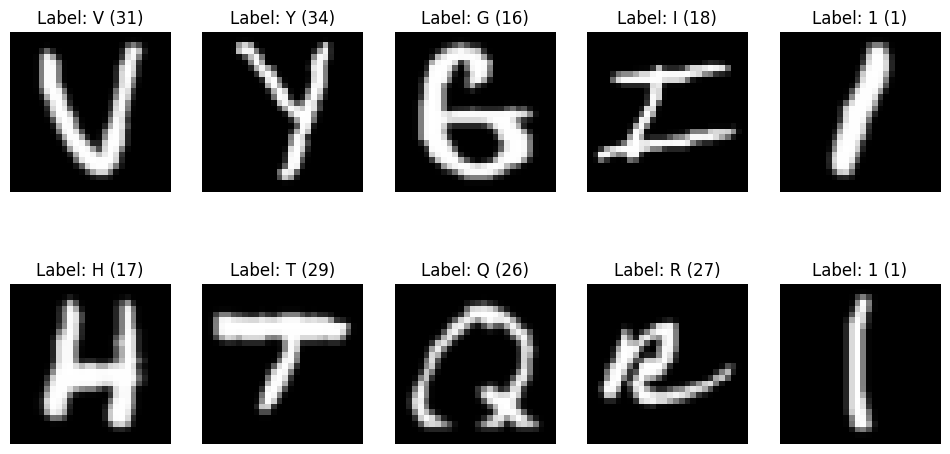

In [3]:
def show_samples(loader):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        label_idx = labels[i].item()
        char = EMNIST_MAPPING.get(label_idx, '?')
        plt.title(f"Label: {char} ({label_idx})")
        plt.axis('off')
    plt.show()

show_samples(train_loader)

## 4. 模型设计: Improved LeNet-5

**原始 LeNet-5 (1998)**: `Conv -> Sigmoid -> AvgPool -> Conv -> Sigmoid -> AvgPool ...`

**设计性改进**: 针对 47 类复杂任务，我们需要增加模型容量并防止过拟合。
1.  **激活函数**: `Sigmoid` -> `ReLU` (解决梯度消失，加速收敛)。
2.  **池化层**: `AvgPool` -> `MaxPool` (提取更显著特征)。
3.  **通道数**: 第一层从 6 增加到 16，第二层从 16 增加到 32 (增加特征提取能力)。
4.  **正则化**: 全连接层加入 `Dropout(0.5)` (防止过拟合)。

In [ ]:
class ImprovedLeNet(nn.Module):
    def __init__(self, num_classes=47):
        super(ImprovedLeNet, self).__init__()
        
        # 特征提取部分 (Feature Extractor)
        self.features = nn.Sequential(
            # Conv1: 1x28x28 -> 16x28x28 (Padding=2 保持尺寸方便计算)
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # -> 16x14x14
            
            # Conv2: 16x14x14 -> 32x10x10
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # -> 32x5x5
        )
        
        # 分类器部分 (Classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 120),
            nn.ReLU(),
            nn.Dropout(0.5), #  改进点：加入 Dropout
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes) # 输出 47 类
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ImprovedLeNet(num_classes=47).to(device)
print(model)

ImprovedLeNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=800, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Linear(in_features=84, out_features=47, bias=True)
  )
)


## 5. 模型训练

使用 `CrossEntropyLoss` 和 `Adam` 优化器。
因为 EMNIST 数据量较大（约 11万张），训练 5 个 Epoch 就能看到不错的效果。

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
history = {'loss': [], 'acc': []}

print(" 开始训练...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if i % 200 == 0:
            print(f"   Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")
            
    epoch_acc = 100 * correct / total
    history['loss'].append(running_loss / len(train_loader))
    history['acc'].append(epoch_acc)
    
    print(f" Epoch {epoch+1} Finished. Avg Loss: {running_loss/len(train_loader):.4f}, Acc: {epoch_acc:.2f}%")

print(" 训练完成！")

🚀 开始训练...
   Epoch 1, Batch 0, Loss: 3.8595
   Epoch 1, Batch 200, Loss: 1.8560
   Epoch 1, Batch 400, Loss: 1.4760
   Epoch 1, Batch 600, Loss: 1.1043
   Epoch 1, Batch 800, Loss: 0.9939
   Epoch 1, Batch 1000, Loss: 0.6768
   Epoch 1, Batch 1200, Loss: 0.9867
   Epoch 1, Batch 1400, Loss: 0.6370
   Epoch 1, Batch 1600, Loss: 0.9816
⏳ Epoch 1 Finished. Avg Loss: 1.2731, Acc: 60.52%
   Epoch 2, Batch 0, Loss: 0.5683
   Epoch 2, Batch 200, Loss: 0.8041
   Epoch 2, Batch 400, Loss: 0.8384
   Epoch 2, Batch 600, Loss: 0.8435
   Epoch 2, Batch 800, Loss: 0.6217
   Epoch 2, Batch 1000, Loss: 0.4545
   Epoch 2, Batch 1200, Loss: 0.4269
   Epoch 2, Batch 1400, Loss: 0.9308
   Epoch 2, Batch 1600, Loss: 1.2200
⏳ Epoch 2 Finished. Avg Loss: 0.7347, Acc: 75.49%
   Epoch 3, Batch 0, Loss: 0.4846
   Epoch 3, Batch 200, Loss: 0.4644
   Epoch 3, Batch 400, Loss: 0.5865
   Epoch 3, Batch 600, Loss: 0.8330
   Epoch 3, Batch 800, Loss: 0.6656
   Epoch 3, Batch 1000, Loss: 0.3938
   Epoch 3, Batch 1200,

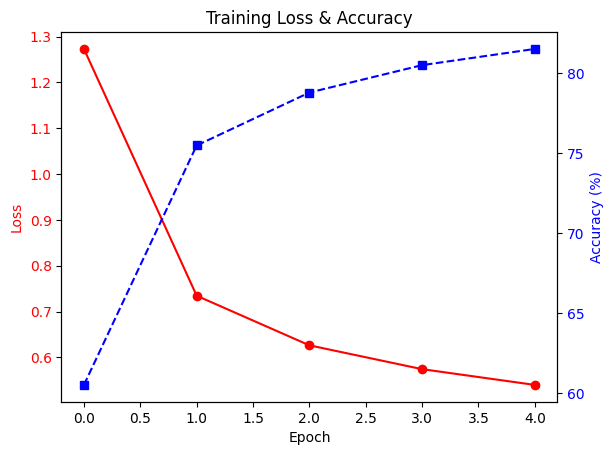

In [6]:
# 绘制训练曲线
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='red')
ax1.plot(history['loss'], color='red', marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='blue')
ax2.plot(history['acc'], color='blue', marker='s', linestyle='--', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Training Loss & Accuracy")
plt.show()

## 6. 模型评估与混淆分析

在测试集上评估，并专门找一找**“易混淆样本”**。
例如：模型到底能不能分清 数字 `0` 和 字母 `O`？

In [11]:
model.eval()
correct = 0
total = 0
confusion_pairs = [] # 记录分错的样本 (图片, 真值, 预测值)

print(" 正在测试集上评估...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # 收集错误样本用于分析
        # 只要找几张分错的存起来
        if len(confusion_pairs) < 10:
            wrong_indices = (predicted != labels).nonzero()
            for idx in wrong_indices:
                if len(confusion_pairs) < 10:
                    idx = idx.item()
                    confusion_pairs.append((inputs[idx].cpu(), labels[idx].item(), predicted[idx].item()))

print(f" 测试集准确率: {100 * correct / total:.2f}%")

 正在测试集上评估...
 测试集准确率: 86.22%


👀 看看模型在哪里犯错了：


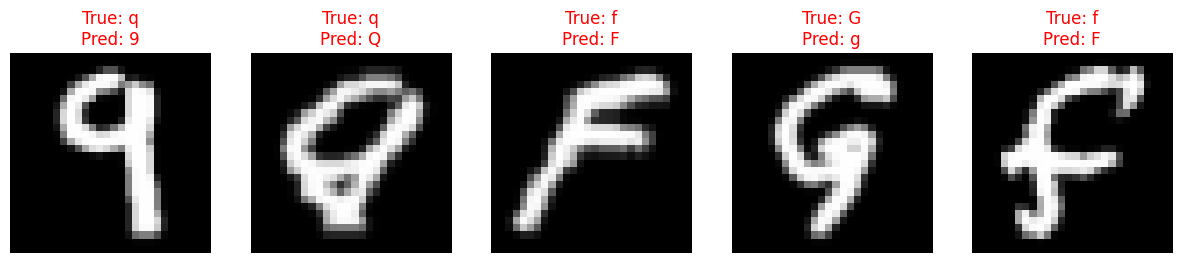

In [ ]:
# 可视化分类错误的样本
print(" 看看模型在哪里犯错了：")
plt.figure(figsize=(15, 3))
for i, (img, true_idx, pred_idx) in enumerate(confusion_pairs[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    
    true_char = EMNIST_MAPPING.get(true_idx, '?')
    pred_char = EMNIST_MAPPING.get(pred_idx, '?')
    
    plt.title(f"True: {true_char}\nPred: {pred_char}", color='red')
    plt.axis('off')
plt.show()

## 7.1 交互式功能 : 混淆分析器 (Confusion Inspector)

**功能说明**：
在下拉菜单中选择一个你想查看的字符（比如 `0` 或 `q`）。
* **上排图片**：模型**预测正确**的样本（Standard）。
* **下排图片**：模型**预测错误**的样本（Mistakes）。

**思考**：看下排的错误样本，是因为写得太潦草，还是因为它长得真的很像另一个字？

In [ ]:
# ==========================================
# 1. 导入必要的库 
# ==========================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch

# ==========================================
# 2. 定义辅助函数 
# ==========================================
def get_char(idx):
    # EMNIST Balanced 映射表
    if idx < 10: return str(idx) # 0-9
    if idx < 36: return chr(idx - 10 + 65) # A-Z
    return 'abdefghnqrt'[idx - 36] # a-z (部分)

# ==========================================
# 3. 初始化交互控件 
# ==========================================
# 生成下拉菜单的选项
label_list = list(range(47)) 
options = [(f"{get_char(k)} (ID:{k})", k) for k in label_list]

# 定义下拉菜单
dropdown = widgets.Dropdown(
    options=options,
    value=0,
    description='选择字符:',
)

# 定义输出区域和按钮
out_inspect = widgets.Output()
btn_inspect = widgets.Button(description="🔍 分析该字符", button_style='info')

# ==========================================
# 4. 定义按钮点击逻辑
# ==========================================
def inspect_char(b):
    target_label = dropdown.value
    target_char = get_char(target_label)
    
    # 防呆检查：确保前面步骤已运行
    if 'test_loader' not in globals():
        with out_inspect:
            clear_output()
            print(" 错误：test_loader 未定义！请先运行【数据加载】代码块。")
        return

    if 'model' not in globals():
        with out_inspect:
            clear_output()
            print(" 错误：model 未定义！请先运行【模型训练】代码块。")
        return

    model.eval()
    correct_samples = []
    wrong_samples = []
    
    with out_inspect:
        clear_output()
        print(f"正在测试集里搜寻 '{target_char}' ...")
        
        try:
            with torch.no_grad():
                count = 0
                for imgs, labels in test_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                    preds = outputs.argmax(dim=1)
                    
                    # 找到所有真实标签是 target_label 的样本
                    mask = (labels == target_label)
                    if mask.sum() == 0: continue
                    
                    target_imgs = imgs[mask]
                    target_preds = preds[mask]
                    
                    for i in range(len(target_imgs)):
                        img = target_imgs[i].cpu().squeeze()
                        pred = target_preds[i].item()
                        
                        if pred == target_label:
                            if len(correct_samples) < 5: correct_samples.append(img)
                        else:
                            if len(wrong_samples) < 5: wrong_samples.append((img, pred))
                    
                    count += len(imgs)
                    if count > 2000: break # 扫描 2000 张就够了
            
            # 绘图逻辑
            fig = plt.figure(figsize=(12, 5))
            
            # 第一行：正确的
            for i, img in enumerate(correct_samples):
                ax = plt.subplot(2, 5, i+1)
                ax.imshow(img, cmap='gray')
                ax.set_title(f"Correct: {target_char}", color='green')
                ax.axis('off')
                
            # 第二行：错误的
            for i, (img, pred) in enumerate(wrong_samples):
                ax = plt.subplot(2, 5, i+6)
                ax.imshow(img, cmap='gray')
                pred_char = get_char(pred)
                ax.set_title(f"Wrong! Pred: {pred_char}", color='red', fontweight='bold')
                ax.axis('off')
                
            if len(wrong_samples) == 0:
                print("🎉 厉害！在扫描的样本中，模型完全识别正确，没有发现错误样本。")
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f" 运行出错: {e}")
            print("请检查 device 变量是否定义，或者模型是否已移动到对应设备。")

# ==========================================
# 5. 绑定事件并显示
# ==========================================
btn_inspect.on_click(inspect_char)
display(widgets.HBox([dropdown, btn_inspect]), out_inspect)

Output()

## 7.2 交互式功能 : 神经网络特征可视化 (Feature Map)

**深度学习是黑盒吗？** 不完全是。
点击下面的按钮，我们可以抽取**第一层卷积层 (Conv1)** 的输出。

* **观察**：你会看到有的图保留了边缘，有的图保留了纹理，这些就是机器眼中的“特征”。

In [ ]:
btn_feature = widgets.Button(description=" 随机抽取并可视化特征图", button_style='warning', layout=widgets.Layout(width='300px'))
out_feature = widgets.Output()

def visualize_features(b):
    with out_feature:
        clear_output()
        
        # 1. 随机取一张图
        idx = np.random.randint(0, len(test_set))
        img_tensor, label = test_set[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device) # [1, 1, 28, 28]
        
        # 2. 提取特征图
        with torch.no_grad():
            x = model.features[0](input_tensor) # Conv1
            feature_maps = model.features[1](x) # ReLU
            feature_maps = feature_maps.cpu().squeeze() # [16, 28, 28]

        # 3. 绘图
        char = get_char(label)
        print(f"当前输入字符: {char}")
        
        # --- 修改点：改成 5 行 5 列 (5, 5)，总容量 25，足够放下索引 21 ---
        plt.figure(figsize=(10, 10)) #稍微调高一点高度
        
        # 原图
        plt.subplot(5, 5, 1) # 修改为 5, 5
        plt.imshow(img_tensor.squeeze(), cmap='gray')
        plt.title("Input Image")
        plt.axis('off')
        
        # 16个特征图
        for i in range(16):
            # i 从 0 到 15
            # 位置从 6 (5+1) 开始，最大到 21 (15+5+1)
            plt.subplot(5, 5, i+5+1) # 修改为 5, 5
            plt.imshow(feature_maps[i], cmap='viridis')
            plt.title(f"Map {i+1}", fontsize=8)
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()

btn_feature.on_click(visualize_features)
display(btn_feature, out_feature)

Button(button_style='warning', description='🎲 随机抽取并可视化特征图', layout=Layout(width='300px'), style=ButtonStyle())

Output()

## 7. 学生拓展与思考

###  思考题

1.  **关于激活函数**：
    原始 LeNet-5 使用的是 `Sigmoid` 或 `Tanh`，为什么现代网络（包括本实验）几乎全用 `ReLU`？如果把代码里的 `ReLU` 换回 `Sigmoid`，训练速度和最终准确率会有什么变化？

2.  **关于形似字混淆**：
    观察上面的错误样本，是否出现了 `0` 被预测为 `O`，或者 `1` 被预测为 `l` / `I` 的情况？
    * 如果是你来设计，有什么办法能让机器更好地区分 `0` 和 `O`？（提示：单纯看形状可能真的分不清，人类是怎么分的？）

3.  **关于网络深度**：
    我们把通道数从 6 加到了 32，但层数没变（还是 2 层卷积）。如果任务变成识别**汉字**（几千类），你觉得应该加深网络（更多层）还是加宽网络（更多通道）？为什么？

###  解答思路

<details>
<summary><strong>点击查看参考答案</strong></summary>

#### 1. ReLU vs Sigmoid
* **梯度消失**: Sigmoid 在输入值很大或很小时，导数接近 0，导致反向传播时梯度消失，深层网络很难训练。ReLU 在正区间导数恒为 1，梯度传导顺畅。
* **计算量**: ReLU 只是 `max(0, x)`，比 Sigmoid 的指数运算快得多。
* **实验预测**: 换回 Sigmoid 后，收敛会变慢，Epoch 1 的 Loss 下降不明显，且最终准确率可能略低。

#### 2. 形似字区分
* **现状**: 单个字符 `0` 和 `O` 在手写体中往往没有本质区别，模型分不清是正常的。
* **解决**: 必须引入**上下文 (Context)**。例如在 "Room 101" 中是数字，在 "HELLO" 中是字母。单纯的 CNN 做不到这一点，需要结合 RNN/Transformer 等序列模型。

#### 3. 汉字识别 (加深 vs 加宽)
* 应该**加深**。汉字结构复杂（偏旁、部首、笔画），需要更深的网络层级来提取从低级（笔画）到高级（结构）的抽象特征。单纯加宽（增加通道）只能增加记忆力，容易过拟合。

</details>